# (6) Single WSI — Curriculum Starting Position

**Step 3**: Verify navigation robustness by progressively increasing start-to-tumor distance.

| Stage | Start Distance | Promotion Condition |
|-------|---------------|---------------------|
| 2a    | 3-5 steps     | success rate > 70%  |
| 2b    | 10-20 steps   | success rate > 70%  |
| 2c    | Any tissue    | final evaluation    |

- Action space: {UP, DOWN, LEFT, RIGHT} — 4 actions, no STOP
- Termination: step on tumor → success; exceed max_steps → timeout
- Reward(same): tumor +50, step -0.01, revisit -0.2, timeout -1.0, background -0.5

## 1. Imports & Configuration

In [ ]:
import os, time, datetime, importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# RL
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

# Project environment
import wsi_env as wsi_env_module
importlib.reload(wsi_env_module)
from wsi_env import WSIEnv

# Paths & constants
H5_PATH = "tile_database/tumor_011.h5"
MAX_STEPS = 2000
EMBEDDING_SUFFIX = "_i"  # ImageNet
RUN_TAG = f"curriculum_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"

REWARD_CFG = dict(
    step_penalty=-0.01,
    revisit_penalty=-0.2,
    tumor_reward=50.0,
    timeout_penalty=-1.0,
    background_penalty=-0.5,
)

print(f"Run tag: {RUN_TAG}")

Run tag: curriculum_20260323_103836


## 2. Distance Map Inspection

Visualize the BFS distance from each tissue tile to the nearest tumor tile, and check that each stage has a reasonable candidate pool size.

In [ ]:
# Create an environment and compute the distance map
env_inspect = WSIEnv(H5_PATH, max_steps=MAX_STEPS, embedding_suffix=EMBEDDING_SUFFIX,
                     start_mode='distance_band', start_dist_range=(3, 5))

dist_map = env_inspect._dist_to_tumor

# Candidate pool sizes per stage
stages = {
    '2a (3-5)': (3, 5),
    '2b (10-20)': (10, 20),
    '2c (all tissue)': (1, 9999),
}
print(f"Grid: {env_inspect.n_rows} x {env_inspect.n_cols}")
print(f"Tissue tiles: {env_inspect.tissue_grid.sum()}")
print(f"Tumor tiles: {env_inspect.tumor_grid.sum()}")
print(f"Max BFS distance: {dist_map[dist_map >= 0].max()}")
print()
for name, (d_min, d_max) in stages.items():
    pool = env_inspect.get_start_pool(d_min, d_max)
    print(f"  Stage {name}: {len(pool)} candidate tiles")

Grid: 493 x 218
Tissue tiles: 24347
Tumor tiles: 1108
Max BFS distance: 125

  Stage 2a (3-5): 884 candidate tiles
  Stage 2b (10-20): 3343 candidate tiles
  Stage 2c (all tissue): 19608 candidate tiles


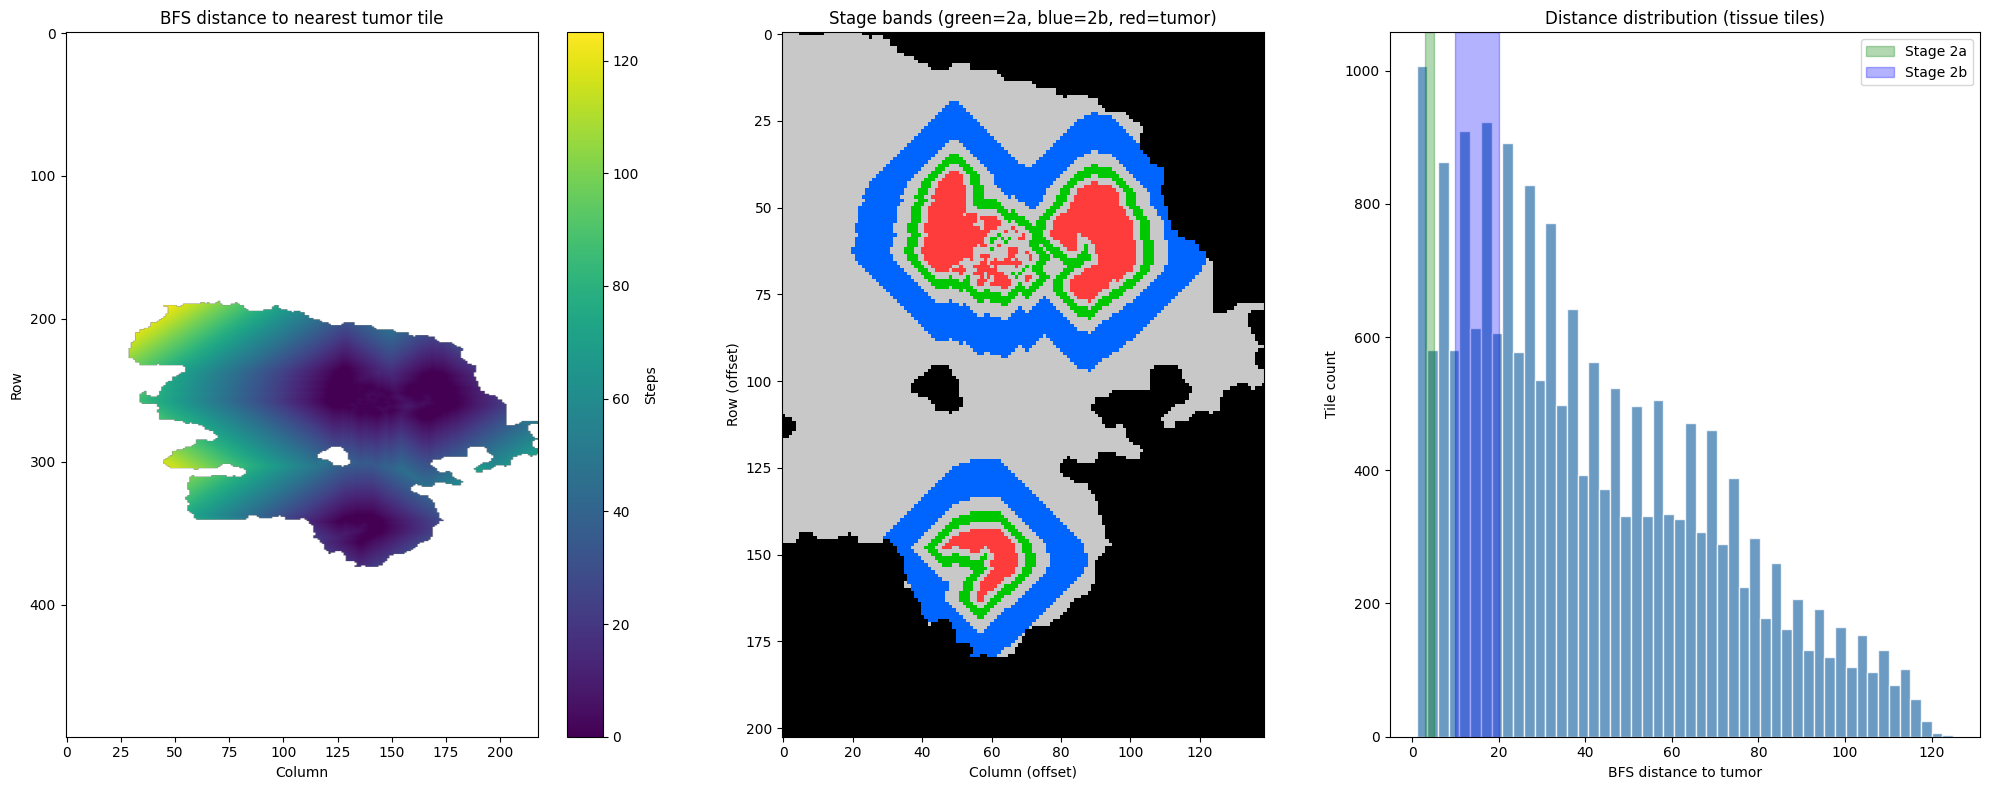

In [ ]:
# Visualize the distance map and stage bands
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Left: distance heatmap
dist_vis = dist_map.copy().astype(float)
dist_vis[dist_vis < 0] = np.nan
im = axes[0].imshow(dist_vis, cmap='viridis', aspect='auto')
axes[0].set_title('BFS distance to nearest tumor tile')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Row')
plt.colorbar(im, ax=axes[0], label='Steps')

# Middle: zoomed tumor area with stage bands
tumor_rows, tumor_cols = np.where(env_inspect.tumor_grid)
margin = 40
r_min = max(tumor_rows.min() - margin, 0)
r_max = min(tumor_rows.max() + margin, env_inspect.n_rows)
c_min = max(tumor_cols.min() - margin, 0)
c_max = min(tumor_cols.max() + margin, env_inspect.n_cols)

canvas = np.zeros((r_max - r_min, c_max - c_min, 3), dtype=np.uint8)
local_tissue = env_inspect.tissue_grid[r_min:r_max, c_min:c_max]
local_tumor = env_inspect.tumor_grid[r_min:r_max, c_min:c_max]
canvas[local_tissue] = [200, 200, 200]
canvas[local_tumor] = [255, 60, 60]

# Overlay stage bands
colors_stage = {'2a (3-5)': [0, 200, 0], '2b (10-20)': [0, 100, 255]}
for name, (d_min, d_max) in list(stages.items())[:2]:
    pool = env_inspect.get_start_pool(d_min, d_max)
    for r, c in pool:
        if r_min <= r < r_max and c_min <= c < c_max:
            canvas[r - r_min, c - c_min] = colors_stage[name]

axes[1].imshow(canvas)
axes[1].set_title('Stage bands (green=2a, blue=2b, red=tumor)')
axes[1].set_xlabel('Column (offset)')
axes[1].set_ylabel('Row (offset)')

# --- Right: distance histogram ---
tissue_dists = dist_map[(dist_map > 0) & env_inspect.tissue_grid & ~env_inspect.tumor_grid]
axes[2].hist(tissue_dists, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvspan(3, 5, alpha=0.3, color='green', label='Stage 2a')
axes[2].axvspan(10, 20, alpha=0.3, color='blue', label='Stage 2b')
axes[2].set_xlabel('BFS distance to tumor')
axes[2].set_ylabel('Tile count')
axes[2].set_title('Distance distribution (tissue tiles)')
axes[2].legend()

plt.tight_layout()
plt.show()
del env_inspect

## 3. Curriculum Training Pipeline

Automatic stage promotion: each stage trains until the success rate exceeds 70% (or hits the timestep cap), then the model weights carry over to the next stage.

In [4]:
class CurriculumCallback(BaseCallback):
    """Track episode stats for curriculum stage evaluation."""

    def __init__(self, check_freq: int = 5000, window: int = 50, verbose: int = 1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.window = window
        self.episode_rewards = []
        self.episode_lengths = []
        self.successes = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        dones = self.locals.get("dones", [])
        if dones is not None:
            for i, done in enumerate(dones):
                if done and infos is not None and i < len(infos):
                    ep = infos[i].get("episode")
                    if ep is not None:
                        self.episode_rewards.append(ep["r"])
                        self.episode_lengths.append(ep["l"])
                    self.successes.append(infos[i].get("success", False))

        if self.num_timesteps % self.check_freq == 0 and len(self.episode_rewards) > 0:
            n = min(self.window, len(self.episode_rewards))
            avg_r = np.mean(self.episode_rewards[-n:])
            avg_l = np.mean(self.episode_lengths[-n:])
            sr = np.mean(self.successes[-n:]) * 100
            print(f"[Step {self.num_timesteps:>7d}] "
                  f"last{n} avg_R={avg_r:+.2f}  avg_L={avg_l:.0f}  "
                  f"SR={sr:.1f}%  eps={len(self.episode_rewards)}")
        return True

    @property
    def recent_success_rate(self) -> float:
        if len(self.successes) < self.window:
            return 0.0
        return float(np.mean(self.successes[-self.window:]))

    def _on_training_end(self):
        n = len(self.episode_rewards)
        if n > 0:
            last = min(50, n)
            print(f"  Stage done: {n} episodes, "
                  f"last{last} avg_R={np.mean(self.episode_rewards[-last:]):+.2f}  "
                  f"avg_L={np.mean(self.episode_lengths[-last:]):.0f}  "
                  f"SR={np.mean(self.successes[-last:])*100:.1f}%")

In [ ]:
# Curriculum stage configuration
STAGE_CONFIG = [
    {"name": "2a", "start_mode": "distance_band", "dist_range": (3, 5),
     "max_timesteps": 200_000, "promote_sr": 0.70},
    {"name": "2b", "start_mode": "distance_band", "dist_range": (10, 20),
     "max_timesteps": 300_000, "promote_sr": 0.70},
    {"name": "2c", "start_mode": "random_tissue", "dist_range": None,
     "max_timesteps": 500_000, "promote_sr": None},  # final stage
]

# PPO hyperparameters
PPO_KWARGS = dict(
    policy="MlpPolicy",
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=0,
    device="cpu",
    seed=42,
)

print("Stage configuration:")
for s in STAGE_CONFIG:
    print(f"  {s['name']}: mode={s['start_mode']}, dist={s['dist_range']}, "
          f"max_steps={s['max_timesteps']}, promote_SR={s['promote_sr']}")

Stage configuration:
  2a: mode=distance_band, dist=(3, 5), max_steps=200000, promote_SR=0.7
  2b: mode=distance_band, dist=(10, 20), max_steps=300000, promote_SR=0.7
  2c: mode=random_tissue, dist=None, max_steps=500000, promote_SR=None


In [ ]:
# Main training loop — train each stage in sequence, carrying weights forward
all_stage_results = {}  # stage_name -> {callback, monitor_dir, ...}
model = None
total_time = 0.0

for stage_i, stage_cfg in enumerate(STAGE_CONFIG):
    stage_name = stage_cfg["name"]
    print(f"\n{'='*60}")
    print(f"STAGE {stage_name} | mode={stage_cfg['start_mode']} | dist={stage_cfg['dist_range']}")
    print(f"{'='*60}")

    # Set up the environment for this stage
    monitor_dir = f"monitor_logs_{RUN_TAG}_stage{stage_name}"
    os.makedirs(monitor_dir, exist_ok=True)

    env = WSIEnv(
        h5_path=H5_PATH,
        max_steps=MAX_STEPS,
        embedding_suffix=EMBEDDING_SUFFIX,
        enable_stop=False,
        start_mode=stage_cfg["start_mode"],
        start_dist_range=stage_cfg["dist_range"],
        reward_cfg=REWARD_CFG,
    )
    env = Monitor(env, monitor_dir)

    # Initialize model on stage 1; reuse weights for subsequent stages
    if model is None:
        model = PPO(
            env=env,
            tensorboard_log=f"./tb_logs_{RUN_TAG}",
            **PPO_KWARGS,
        )
    else:
        # Carry over the previous stage's weights
        model.set_env(env)

    # Train in 50K-step blocks; check for promotion after each block
    CHECK_BLOCK = 50_000
    trained_steps = 0
    promoted = False
    callback = CurriculumCallback(check_freq=10000, window=50)

    t0 = time.time()
    while trained_steps < stage_cfg["max_timesteps"]:
        block = min(CHECK_BLOCK, stage_cfg["max_timesteps"] - trained_steps)
        model.learn(total_timesteps=block, callback=callback, reset_num_timesteps=False)
        trained_steps += block

        sr = callback.recent_success_rate
        n_eps = len(callback.episode_rewards)
        print(f"  >> Checkpoint @ {trained_steps} steps: SR={sr*100:.1f}%  episodes={n_eps}")

        # Try to promote (skip check for the final stage)
        if stage_cfg["promote_sr"] is not None and sr >= stage_cfg["promote_sr"]:
            print(f"  >> PROMOTED! SR={sr*100:.1f}% >= {stage_cfg['promote_sr']*100:.0f}%")
            promoted = True
            break

    elapsed = time.time() - t0
    total_time += elapsed
    print(f"  Stage {stage_name} finished: {trained_steps} steps in {elapsed:.1f}s")

    all_stage_results[stage_name] = {
        "callback": callback,
        "monitor_dir": monitor_dir,
        "trained_steps": trained_steps,
        "promoted": promoted,
        "elapsed": elapsed,
    }

    env.close()

print(f"\nTotal training time: {total_time:.1f}s ({total_time/60:.1f}min)")


STAGE 2a | mode=distance_band | dist=(3, 5)
[Step   10000] last50 avg_R=+27.12  avg_L=159  SR=98.0%  eps=52
[Step   20000] last50 avg_R=+21.15  avg_L=253  SR=90.0%  eps=83
[Step   30000] last50 avg_R=+12.45  avg_L=359  SR=86.0%  eps=103
[Step   40000] last50 avg_R=+18.94  avg_L=384  SR=84.0%  eps=132
[Step   50000] last50 avg_R=+12.45  avg_L=500  SR=76.0%  eps=149
  Stage done: 149 episodes, last50 avg_R=+12.45  avg_L=500  SR=76.0%
  >> Checkpoint @ 50000 steps: SR=76.0%  episodes=149
  >> PROMOTED! SR=76.0% >= 70%
  Stage 2a finished: 50000 steps in 76.8s

STAGE 2b | mode=distance_band | dist=(10, 20)
[Step   60000] last8 avg_R=-10.32  avg_L=1022  SR=50.0%  eps=8
[Step   70000] last13 avg_R=-45.66  avg_L=1398  SR=30.8%  eps=13
[Step   80000] last23 avg_R=-23.01  avg_L=1179  SR=43.5%  eps=23
[Step   90000] last33 avg_R=-31.99  avg_L=1115  SR=48.5%  eps=33
[Step  100000] last42 avg_R=-33.82  avg_L=1127  SR=47.6%  eps=42
  Stage done: 44 episodes, last44 avg_R=-31.80  avg_L=1122  SR=47.

## 4. Training Curves per Stage

Stage 2a: 149 episodes | last50 avg_R=+12.45  avg_L=499.9  SR=76.0% | promoted=True
Stage 2b: 271 episodes | last50 avg_R=-0.87  avg_L=1254.3  SR=38.0% | promoted=False
Stage 2c: 331 episodes | last50 avg_R=-11.06  avg_L=1570.9  SR=22.0% | promoted=False


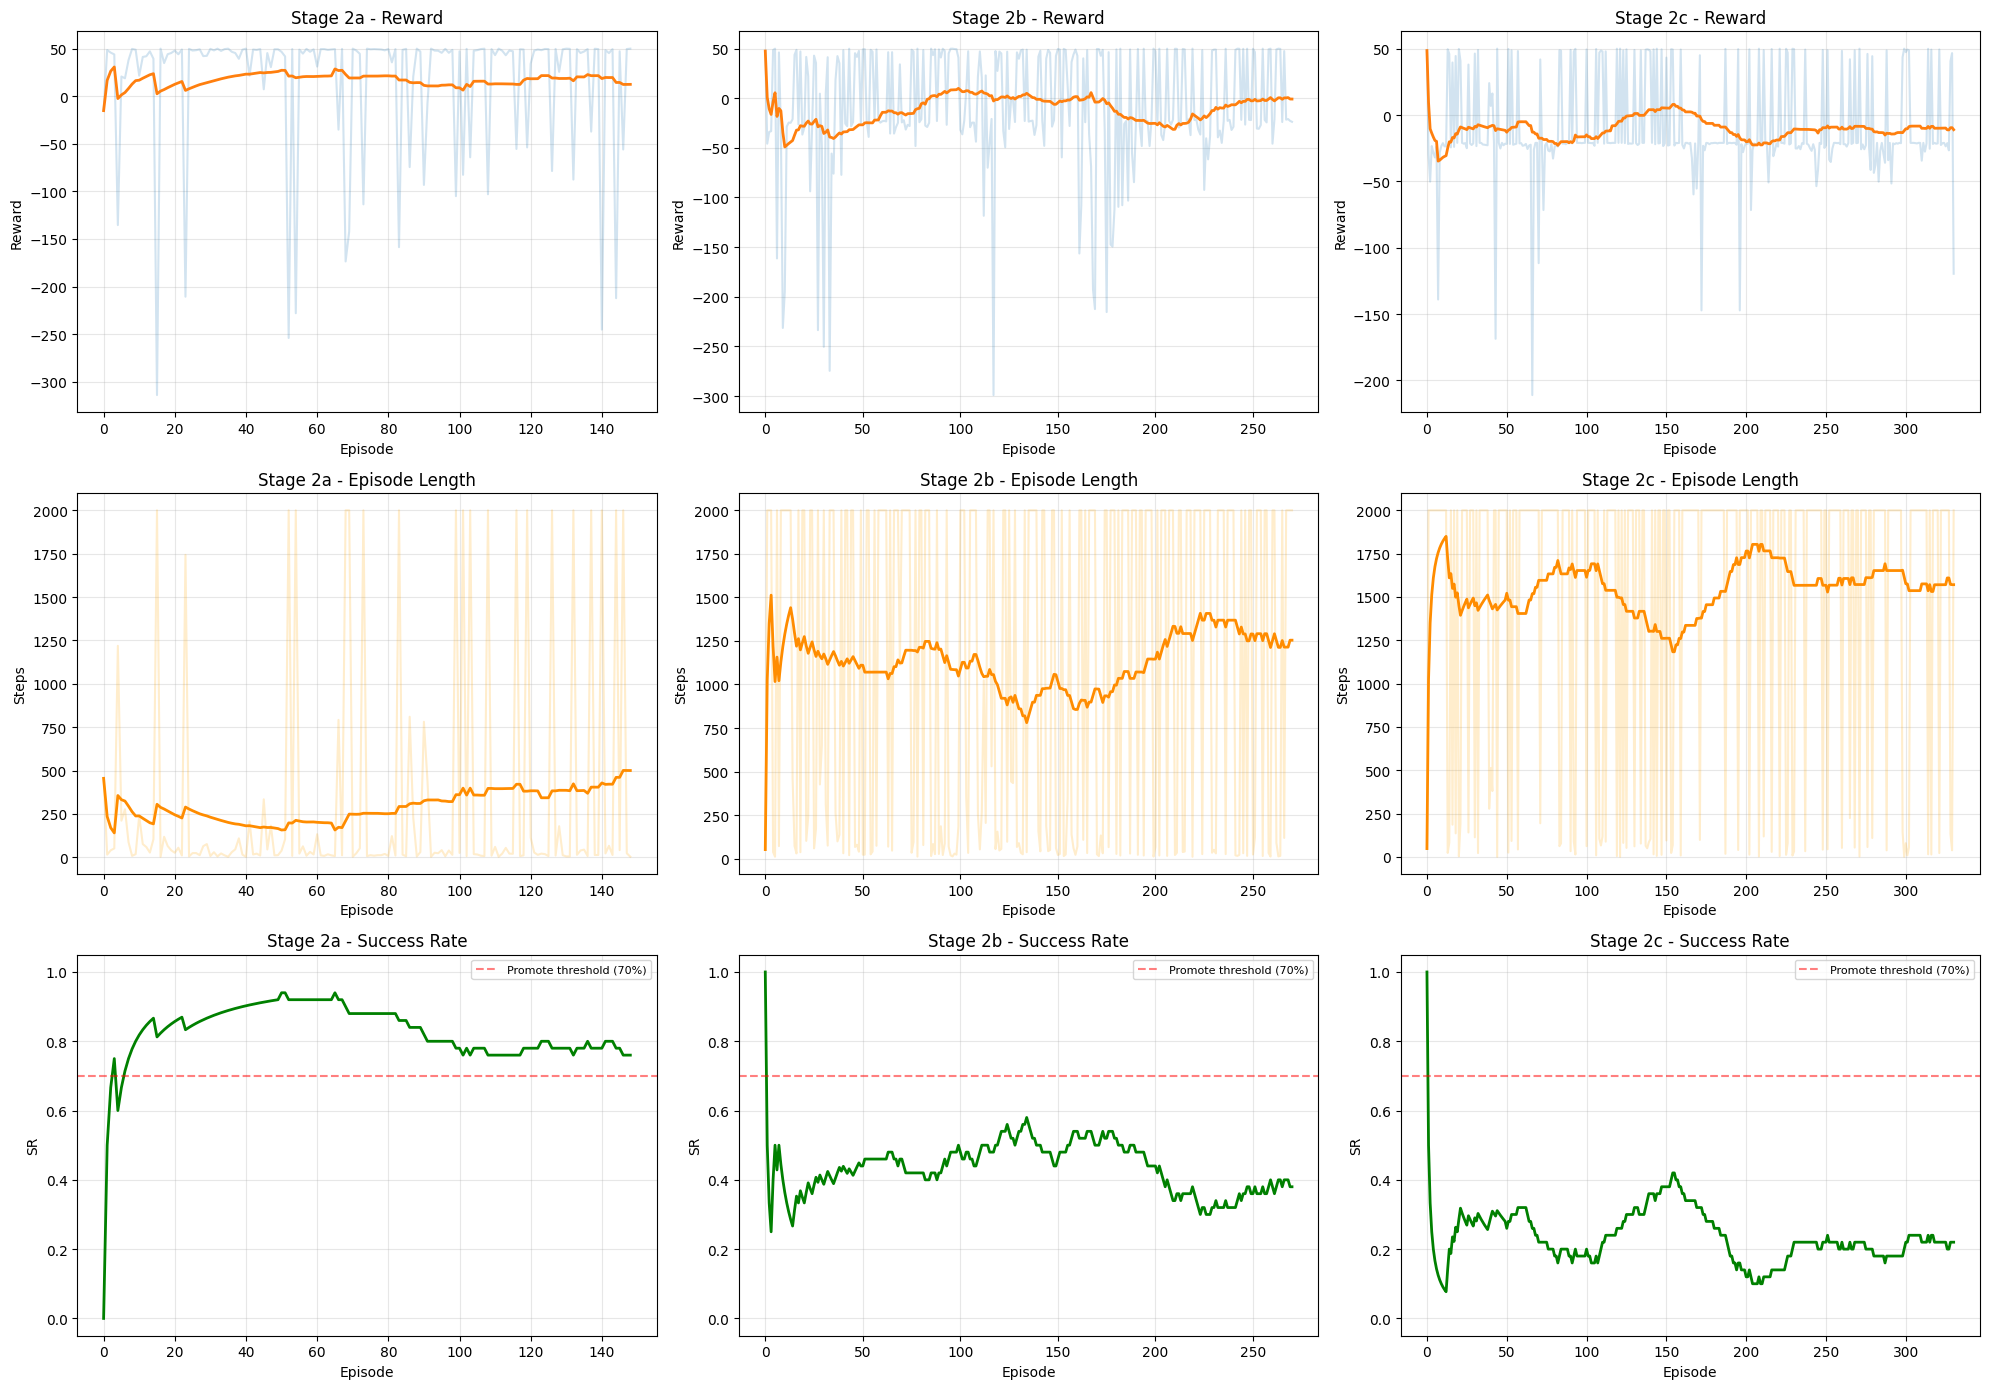

In [ ]:
# Load per-stage monitor CSVs and plot learning curves
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
window = 50

for col_i, (stage_name, sres) in enumerate(all_stage_results.items()):
    mdir = sres["monitor_dir"]
    csvs = [f for f in os.listdir(mdir) if f.endswith(".csv")]
    if not csvs:
        continue
    df = pd.read_csv(os.path.join(mdir, csvs[0]), skiprows=1)
    df["reward_ma"] = df["r"].rolling(window, min_periods=1).mean()
    df["length_ma"] = df["l"].rolling(window, min_periods=1).mean()
    df["success"] = (df["r"] > 0).astype(float)
    df["success_ma"] = df["success"].rolling(window, min_periods=1).mean()

    # Reward
    ax = axes[0, col_i]
    ax.plot(df.index, df["r"], alpha=0.2)
    ax.plot(df.index, df["reward_ma"], linewidth=2)
    ax.set_title(f"Stage {stage_name} - Reward")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.grid(True, alpha=0.3)

    # Length
    ax = axes[1, col_i]
    ax.plot(df.index, df["l"], alpha=0.2, color="orange")
    ax.plot(df.index, df["length_ma"], linewidth=2, color="darkorange")
    ax.set_title(f"Stage {stage_name} - Episode Length")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Steps")
    ax.grid(True, alpha=0.3)

    # Success rate
    ax = axes[2, col_i]
    ax.plot(df.index, df["success_ma"], linewidth=2, color="green")
    ax.axhline(y=0.7, color="red", linestyle="--", alpha=0.5, label="Promote threshold (70%)")
    ax.set_title(f"Stage {stage_name} - Success Rate")
    ax.set_xlabel("Episode")
    ax.set_ylabel("SR")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Print summary
    last_n = min(50, len(df))
    print(f"Stage {stage_name}: {len(df)} episodes | "
          f"last{last_n} avg_R={df['r'].tail(last_n).mean():+.2f}  "
          f"avg_L={df['l'].tail(last_n).mean():.1f}  "
          f"SR={df['success'].tail(last_n).mean()*100:.1f}% | "
          f"promoted={sres['promoted']}")

plt.tight_layout()
plt.show()

## 5. Deterministic Evaluation per Stage

Sample start positions from each stage's candidate pool and run deterministic rollouts. Reports success rates, episode lengths, and average rewards.

In [8]:
def evaluate_from_pool(model, h5_path, start_mode, dist_range,
                       n_episodes=50, max_steps=2000, seed=123):
    """Run deterministic evaluation from sampled starting positions."""
    env = WSIEnv(
        h5_path=h5_path,
        max_steps=max_steps,
        embedding_suffix=EMBEDDING_SUFFIX,
        enable_stop=False,
        start_mode=start_mode,
        start_dist_range=dist_range,
    )

    rng = np.random.RandomState(seed)
    if start_mode == 'distance_band' and dist_range is not None:
        pool = env.get_start_pool(dist_range[0], dist_range[1])
    else:
        pool = np.argwhere(env.tissue_grid & ~env.tumor_grid)

    # 采样起始点
    indices = rng.choice(len(pool), size=min(n_episodes, len(pool)), replace=False)
    starts = [(int(pool[i][0]), int(pool[i][1])) for i in indices]

    results = []
    for start in starts:
        env.fixed_starts = [start]
        env.start_mode = 'fixed'
        env._start_idx = 0

        obs, info = env.reset()
        trajectory = [(info['row'], info['col'])]
        total_r = 0.0
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            trajectory.append((info['row'], info['col']))
            total_r += reward
            done = terminated or truncated

        results.append({
            'start': start,
            'trajectory': trajectory,
            'reward': total_r,
            'length': len(trajectory) - 1,
            'success': info.get('success', False),
        })

    env.close()
    return results

In [ ]:
# Evaluate the final model across all three distance pools
eval_configs = [
    ('2a (3-5)', 'distance_band', (3, 5)),
    ('2b (10-20)', 'distance_band', (10, 20)),
    ('2c (all tissue)', 'random_tissue', None),
]

eval_results = {}
for eval_name, mode, dr in eval_configs:
    res = evaluate_from_pool(model, H5_PATH, mode, dr, n_episodes=50)
    successes = sum(1 for r in res if r['success'])
    lengths = [r['length'] for r in res]
    rewards = [r['reward'] for r in res]
    eval_results[eval_name] = res

    print(f"Eval [{eval_name}]: {successes}/{len(res)} success "
          f"({successes/len(res)*100:.1f}%)  "
          f"avg_len={np.mean(lengths):.1f}  avg_R={np.mean(rewards):+.2f}")

Eval [2a (3-5)]: 16/50 success (32.0%)  avg_len=1361.5  avg_R=-269.55
Eval [2b (10-20)]: 4/50 success (8.0%)  avg_len=1841.4  avg_R=-326.27
Eval [2c (all tissue)]: 1/50 success (2.0%)  avg_len=1960.4  avg_R=-290.33


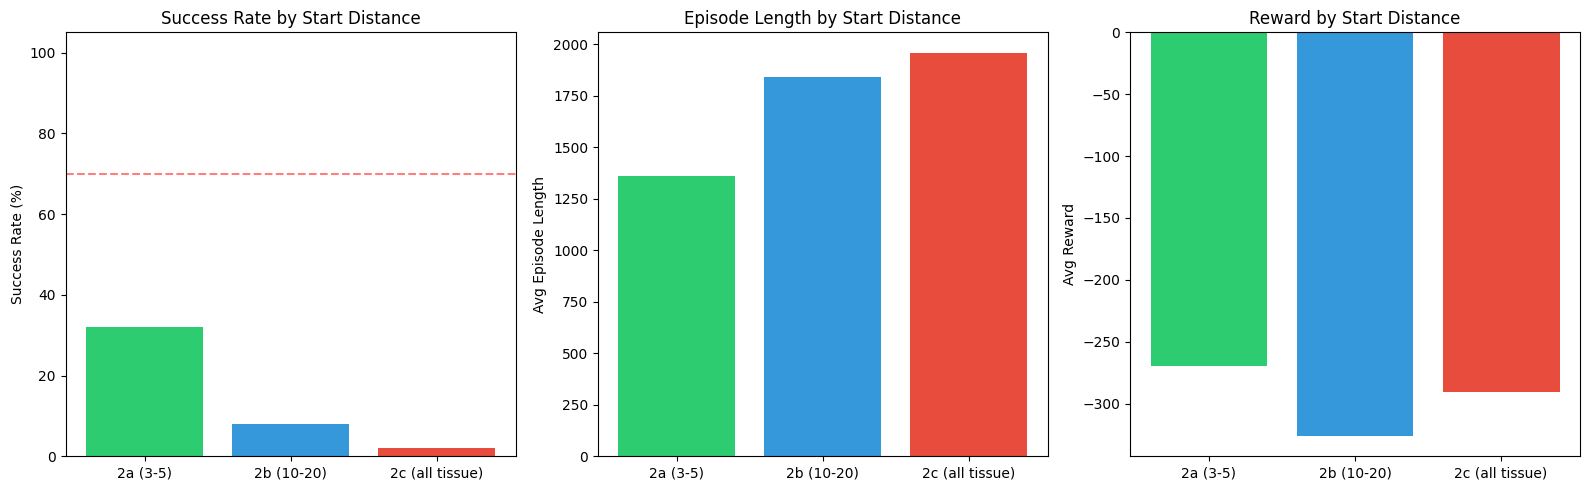

In [ ]:
# Bar charts comparing success rate, length, and reward across distance stages
eval_names = list(eval_results.keys())
eval_sr = [np.mean([r['success'] for r in eval_results[n]]) * 100 for n in eval_names]
eval_len = [np.mean([r['length'] for r in eval_results[n]]) for n in eval_names]
eval_rew = [np.mean([r['reward'] for r in eval_results[n]]) for n in eval_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].bar(eval_names, eval_sr, color=colors)
axes[0].axhline(y=70, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_title('Success Rate by Start Distance')
axes[0].set_ylim(0, 105)

axes[1].bar(eval_names, eval_len, color=colors)
axes[1].set_ylabel('Avg Episode Length')
axes[1].set_title('Episode Length by Start Distance')

axes[2].bar(eval_names, eval_rew, color=colors)
axes[2].set_ylabel('Avg Reward')
axes[2].set_title('Reward by Start Distance')

plt.tight_layout()
plt.show()

## 6. Trajectory Visualization (Sample Episodes)

Pick a handful of success and failure episodes from Stage 2c (the hardest) and plot the actual navigation paths.

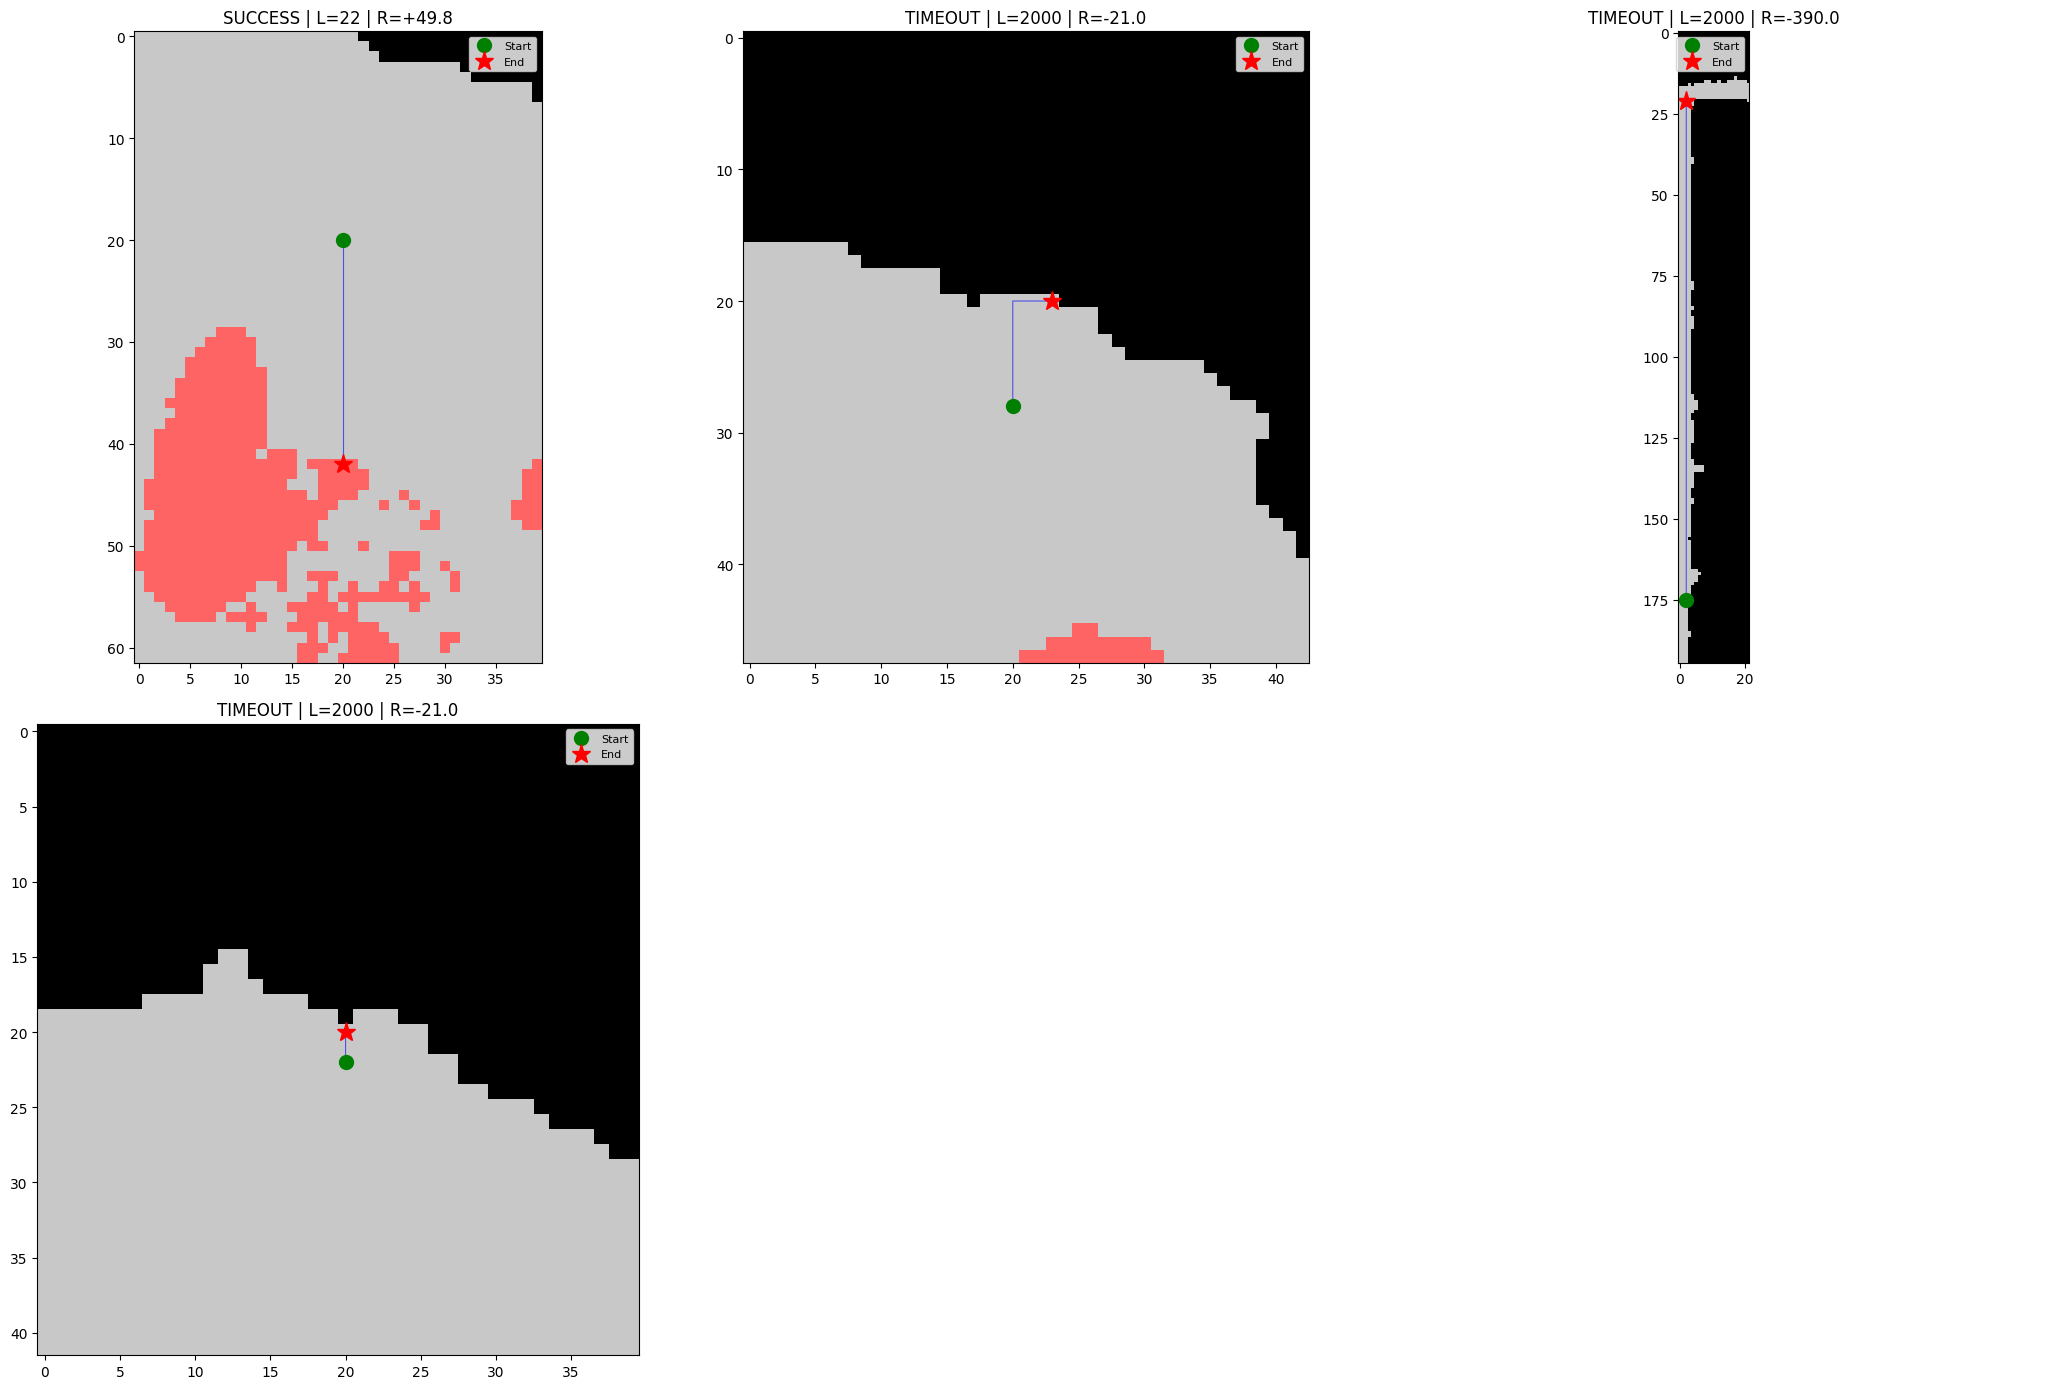

In [ ]:
# Grab sample episodes from the 2c evaluation for visualization
vis_env = WSIEnv(H5_PATH, max_steps=MAX_STEPS, embedding_suffix=EMBEDDING_SUFFIX)

res_2c = eval_results['2c (all tissue)']
success_eps = [r for r in res_2c if r['success']]
fail_eps = [r for r in res_2c if not r['success']]

# Up to 3 shortest successes + 3 shortest failures
show_eps = []
if success_eps:
    show_eps += sorted(success_eps, key=lambda x: x['length'])[:3]  # shortest successes
if fail_eps:
    show_eps += sorted(fail_eps, key=lambda x: x['length'])[:3]    # shortest failures

n_show = len(show_eps)
if n_show > 0:
    cols = min(n_show, 3)
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 7 * rows), squeeze=False)

    for idx, ep in enumerate(show_eps):
        ax = axes[idx // cols][idx % cols]
        traj = ep['trajectory']

        # Local bounding box
        traj_r = [p[0] for p in traj]
        traj_c = [p[1] for p in traj]
        margin = 20
        r_min = max(min(traj_r) - margin, 0)
        r_max = min(max(traj_r) + margin, vis_env.n_rows)
        c_min = max(min(traj_c) - margin, 0)
        c_max = min(max(traj_c) + margin, vis_env.n_cols)

        canvas = np.zeros((r_max - r_min, c_max - c_min, 3), dtype=np.uint8)
        canvas[vis_env.tissue_grid[r_min:r_max, c_min:c_max]] = [200, 200, 200]
        canvas[vis_env.tumor_grid[r_min:r_max, c_min:c_max]] = [255, 100, 100]

        ax.imshow(canvas)
        cols_p = [p[1] - c_min for p in traj]
        rows_p = [p[0] - r_min for p in traj]
        ax.plot(cols_p, rows_p, color='blue', linewidth=0.8, alpha=0.6)
        ax.plot(cols_p[0], rows_p[0], 'go', markersize=10, label='Start')
        ax.plot(cols_p[-1], rows_p[-1], 'r*', markersize=14, label='End')

        status = 'SUCCESS' if ep['success'] else 'TIMEOUT'
        ax.set_title(f"{status} | L={ep['length']} | R={ep['reward']:+.1f}")
        ax.legend(fontsize=8, loc='upper right')

    # Hide any unused subplot axes
    for idx in range(n_show, rows * cols):
        axes[idx // cols][idx % cols].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No episodes to visualize.")

del vis_env

## 7. Summary & Next Steps

Aggregate training and evaluation stats across all stages.

In [12]:
print("=" * 70)
print("CURRICULUM TRAINING SUMMARY")
print("=" * 70)
for stage_name, sres in all_stage_results.items():
    cb = sres['callback']
    n = len(cb.episode_rewards)
    last = min(50, n)
    sr = np.mean(cb.successes[-last:]) * 100 if n > 0 else 0
    avg_r = np.mean(cb.episode_rewards[-last:]) if n > 0 else 0
    avg_l = np.mean(cb.episode_lengths[-last:]) if n > 0 else 0
    print(f"Stage {stage_name}: {sres['trained_steps']:>7d} steps | "
          f"{n} episodes | last{last} SR={sr:.1f}% avg_R={avg_r:+.2f} avg_L={avg_l:.0f} | "
          f"promoted={sres['promoted']} | time={sres['elapsed']:.0f}s")

print()
print("EVALUATION ON FINAL MODEL:")
for eval_name, res in eval_results.items():
    sr = np.mean([r['success'] for r in res]) * 100
    avg_l = np.mean([r['length'] for r in res])
    avg_r = np.mean([r['reward'] for r in res])
    print(f"  {eval_name}: SR={sr:.1f}%  avg_L={avg_l:.1f}  avg_R={avg_r:+.2f}")

CURRICULUM TRAINING SUMMARY
Stage 2a:   50000 steps | 149 episodes | last50 SR=76.0% avg_R=+12.45 avg_L=500 | promoted=True | time=77s
Stage 2b:  300000 steps | 271 episodes | last50 SR=38.0% avg_R=-0.87 avg_L=1254 | promoted=False | time=448s
Stage 2c:  500000 steps | 331 episodes | last50 SR=22.0% avg_R=-11.06 avg_L=1571 | promoted=False | time=754s

EVALUATION ON FINAL MODEL:
  2a (3-5): SR=32.0%  avg_L=1361.5  avg_R=-269.55
  2b (10-20): SR=8.0%  avg_L=1841.4  avg_R=-326.27
  2c (all tissue): SR=2.0%  avg_L=1960.4  avg_R=-290.33


## 8. Diagnosis & Fix: Mixed-Distance Training

The results above show signs of **catastrophic forgetting**: the sequential curriculum caused later stages to overwrite what the agent learned in stage 2a. The final model ends up at just 32% SR even on 3–5 step starts.

The underlying issue is fairly straightforward. Once we switch to a longer-distance stage, nearly every episode times out, and those failure gradients wash out the earlier policy. An MLP has no way to separate "close range" from "far range" behavior — it just forgets.

**Fix: mixed-distance training.** Rather than switching stages, sample start positions uniformly from all tissue tiles throughout training. This keeps a steady stream of easy (near-tumor) episodes that reinforce the existing policy while the agent gradually encounters harder starts.

Concrete changes:
- `start_mode="random_tissue"` — sample from the full tissue pool each episode
- Wider network: 256×256 (obs dim is 1660, the original 64×64 is undersized)
- Longer training: 500K steps
- Added wall bump penalty to discourage the agent from looping at tile boundaries

In [ ]:
# Mixed-distance training: random start from all tissue tiles
RUN_TAG_V2 = f"mixed_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
monitor_dir_v2 = f"monitor_logs_{RUN_TAG_V2}"
os.makedirs(monitor_dir_v2, exist_ok=True)

# Wall bump penalty fires inside WSIEnv when moved==False
env_v2 = WSIEnv(
    h5_path=H5_PATH,
    max_steps=MAX_STEPS,
    embedding_suffix=EMBEDDING_SUFFIX,
    enable_stop=False,
    start_mode="random_tissue",    # sample uniformly from all tissue tiles
    reward_cfg=dict(
        step_penalty=-0.01,
        revisit_penalty=-0.2,
        tumor_reward=50.0,
        timeout_penalty=-1.0,
        background_penalty=-0.5,
    ),
)
env_v2 = Monitor(env_v2, monitor_dir_v2)

TOTAL_TIMESTEPS_V2 = 500_000

model_v2 = PPO(
    policy="MlpPolicy",
    env=env_v2,
    learning_rate=3e-4,
    n_steps=4096,        # larger rollout buffer
    batch_size=512,
    n_epochs=10,
    gamma=0.999,         # higher discount for longer-horizon rewards
    gae_lambda=0.98,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=0,
    device="cpu",
    policy_kwargs=dict(net_arch=[256, 256]),  # wider network
    tensorboard_log=f"./tb_logs_{RUN_TAG_V2}",
    seed=42,
)

print(f"Model v2: {model_v2.policy.mlp_extractor}")
print(f"Total timesteps: {TOTAL_TIMESTEPS_V2}")
print(f"Monitor: {monitor_dir_v2}")

Model v2: MlpExtractor(
  (policy_net): Sequential(
    (0): Linear(in_features=1660, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
  )
  (value_net): Sequential(
    (0): Linear(in_features=1660, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
  )
)
Total timesteps: 500000
Monitor: monitor_logs_mixed_20260323_005812


In [ ]:
# Train the mixed-distance model
callback_v2 = CurriculumCallback(check_freq=10000, window=50)
t0 = time.time()
model_v2.learn(total_timesteps=TOTAL_TIMESTEPS_V2, callback=callback_v2)
elapsed_v2 = time.time() - t0
print(f"\nMixed training completed in {elapsed_v2:.1f}s ({elapsed_v2/60:.1f}min)")

[Step   10000] last5 avg_R=-299.32  avg_L=2000  SR=0.0%  eps=5
[Step   20000] last11 avg_R=-219.73  avg_L=1669  SR=18.2%  eps=11
[Step   30000] last17 avg_R=-192.48  avg_L=1673  SR=17.6%  eps=17
[Step   40000] last23 avg_R=-184.68  avg_L=1682  SR=17.4%  eps=23
[Step   50000] last30 avg_R=-161.27  avg_L=1639  SR=20.0%  eps=30
[Step   60000] last35 avg_R=-144.11  avg_L=1691  SR=17.1%  eps=35
[Step   70000] last40 avg_R=-129.86  avg_L=1730  SR=15.0%  eps=40
[Step   80000] last45 avg_R=-118.78  avg_L=1760  SR=13.3%  eps=45
[Step   90000] last50 avg_R=-109.57  avg_L=1784  SR=12.0%  eps=50
[Step  100000] last50 avg_R=-75.02  avg_L=1742  SR=14.0%  eps=57
[Step  110000] last50 avg_R=-59.78  avg_L=1777  SR=12.0%  eps=62
[Step  120000] last50 avg_R=-48.96  avg_L=1815  SR=10.0%  eps=67
[Step  130000] last50 avg_R=-36.72  avg_L=1850  SR=8.0%  eps=72
[Step  140000] last50 avg_R=-27.02  avg_L=1890  SR=6.0%  eps=77
[Step  150000] last50 avg_R=-23.24  avg_L=1888  SR=6.0%  eps=83
[Step  160000] last50 

### 8.2 Mixed-Distance Model Evaluation

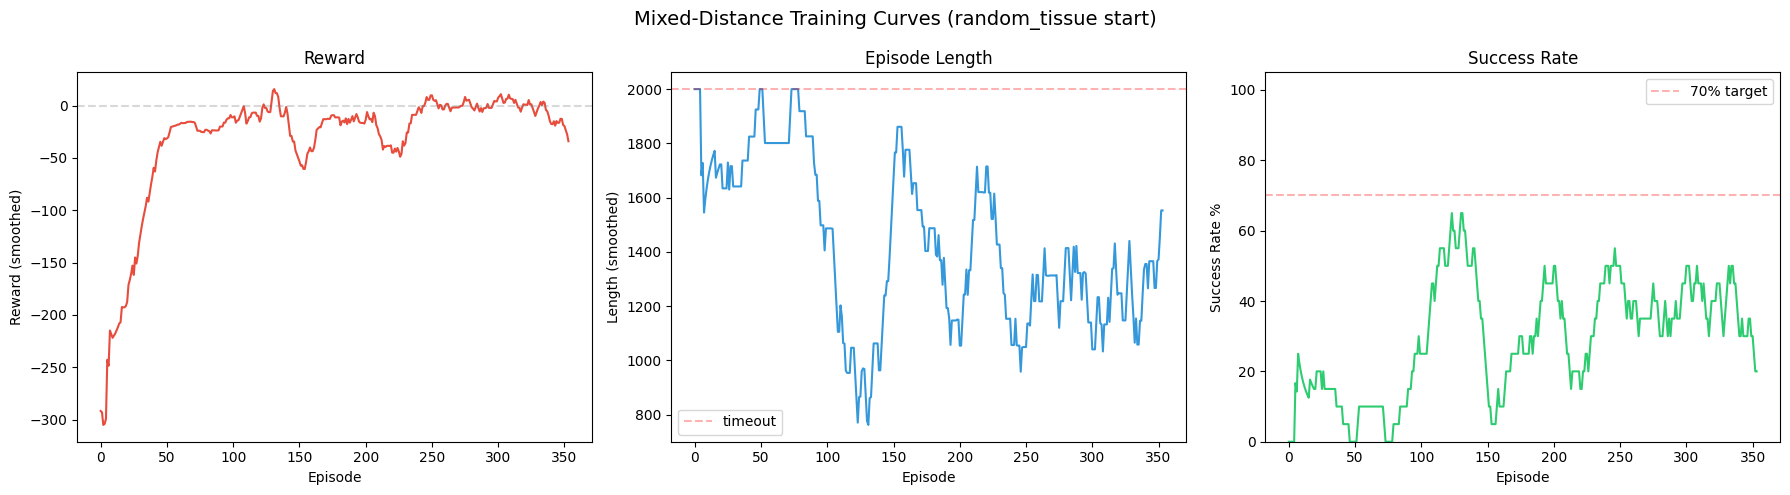

Total episodes: 354
Last 50: avg_R=-13.06, avg_L=1329.9, SR=34.0%


In [ ]:
# Training curves
df_v2 = pd.read_csv(os.path.join(monitor_dir_v2, "monitor.csv"), skiprows=1)
df_v2.columns = ['r', 'l', 't']

window_v2 = 20
df_v2['r_smooth'] = df_v2['r'].rolling(window_v2, min_periods=1).mean()
df_v2['l_smooth'] = df_v2['l'].rolling(window_v2, min_periods=1).mean()
df_v2['success'] = (df_v2['r'] > 0).astype(float)
df_v2['sr_smooth'] = df_v2['success'].rolling(window_v2, min_periods=1).mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Mixed-Distance Training Curves (random_tissue start)', fontsize=14)

axes[0].plot(df_v2['r_smooth'], color='#e74c3c')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward (smoothed)')
axes[0].set_title('Reward'); axes[0].axhline(0, color='gray', ls='--', alpha=0.3)

axes[1].plot(df_v2['l_smooth'], color='#3498db')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Length (smoothed)')
axes[1].set_title('Episode Length'); axes[1].axhline(2000, color='red', ls='--', alpha=0.3, label='timeout')
axes[1].legend()

axes[2].plot(df_v2['sr_smooth'], color='#2ecc71')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Success Rate %')
axes[2].set_title('Success Rate'); axes[2].axhline(70, color='red', ls='--', alpha=0.3, label='70% target')
axes[2].set_ylim(0, 105); axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Total episodes: {len(df_v2)}")
print(f"Last 50: avg_R={df_v2['r'].tail(50).mean():+.2f}, "
      f"avg_L={df_v2['l'].tail(50).mean():.1f}, "
      f"SR={df_v2['success'].tail(50).mean()*100:.1f}%")

In [ ]:
# Deterministic evaluation from 3 distance pools
eval_results_v2 = {}
for eval_name, mode, dr in eval_configs:
    res = evaluate_from_pool(model_v2, H5_PATH, mode, dr, n_episodes=50)
    successes = sum(1 for r in res if r['success'])
    lengths = [r['length'] for r in res]
    rewards = [r['reward'] for r in res]
    eval_results_v2[eval_name] = res

    print(f"Eval [{eval_name}]: {successes}/{len(res)} success "
          f"({successes/len(res)*100:.1f}%)  "
          f"avg_len={np.mean(lengths):.1f}  avg_R={np.mean(rewards):+.2f}")

Eval [2a (3-5)]: 24/50 success (48.0%)  avg_len=1042.8  avg_R=-145.74
Eval [2b (10-20)]: 10/50 success (20.0%)  avg_len=1607.6  avg_R=-189.16
Eval [2c (all tissue)]: 3/50 success (6.0%)  avg_len=1881.3  avg_R=-174.73


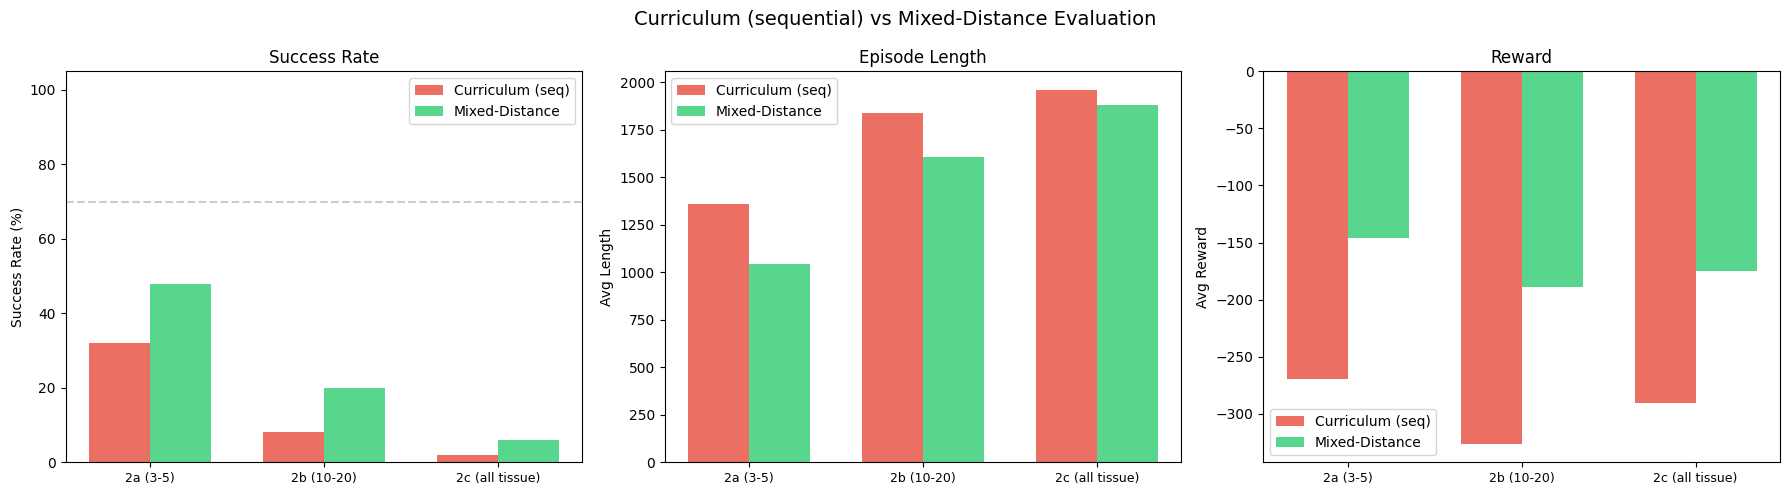


Model                2a (3-5)           2b (10-20)         2c (all tissue)   
Curriculum (seq)      32.0%  L=1361.5    8.0%  L=1841.4    2.0%  L=1960.4
Mixed-Distance        48.0%  L=1042.8   20.0%  L=1607.6    6.0%  L=1881.3


In [ ]:
# Comparison: Curriculum vs Mixed-Distance
eval_names = list(eval_results_v2.keys())

# Curriculum model eval (from earlier)
sr_curriculum = [np.mean([r['success'] for r in eval_results[n]]) * 100 for n in eval_names]
# Mixed model eval
sr_mixed = [np.mean([r['success'] for r in eval_results_v2[n]]) * 100 for n in eval_names]

x = np.arange(len(eval_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curriculum (sequential) vs Mixed-Distance Evaluation', fontsize=14)

# SR comparison
axes[0].bar(x - width/2, sr_curriculum, width, label='Curriculum (seq)', color='#e74c3c', alpha=0.8)
axes[0].bar(x + width/2, sr_mixed, width, label='Mixed-Distance', color='#2ecc71', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(eval_names, fontsize=9)
axes[0].set_ylabel('Success Rate (%)'); axes[0].set_title('Success Rate')
axes[0].axhline(70, color='gray', ls='--', alpha=0.4); axes[0].set_ylim(0, 105)
axes[0].legend()

# Length comparison
len_curriculum = [np.mean([r['length'] for r in eval_results[n]]) for n in eval_names]
len_mixed = [np.mean([r['length'] for r in eval_results_v2[n]]) for n in eval_names]
axes[1].bar(x - width/2, len_curriculum, width, label='Curriculum (seq)', color='#e74c3c', alpha=0.8)
axes[1].bar(x + width/2, len_mixed, width, label='Mixed-Distance', color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(eval_names, fontsize=9)
axes[1].set_ylabel('Avg Length'); axes[1].set_title('Episode Length')
axes[1].legend()

# Reward comparison
rew_curriculum = [np.mean([r['reward'] for r in eval_results[n]]) for n in eval_names]
rew_mixed = [np.mean([r['reward'] for r in eval_results_v2[n]]) for n in eval_names]
axes[2].bar(x - width/2, rew_curriculum, width, label='Curriculum (seq)', color='#e74c3c', alpha=0.8)
axes[2].bar(x + width/2, rew_mixed, width, label='Mixed-Distance', color='#2ecc71', alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(eval_names, fontsize=9)
axes[2].set_ylabel('Avg Reward'); axes[2].set_title('Reward')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print(f"{'Model':<20} {'2a (3-5)':<18} {'2b (10-20)':<18} {'2c (all tissue)':<18}")
print("="*70)
print(f"{'Curriculum (seq)':<20} {sr_curriculum[0]:>5.1f}%  L={len_curriculum[0]:>6.1f}"
      f"  {sr_curriculum[1]:>5.1f}%  L={len_curriculum[1]:>6.1f}"
      f"  {sr_curriculum[2]:>5.1f}%  L={len_curriculum[2]:>6.1f}")
print(f"{'Mixed-Distance':<20} {sr_mixed[0]:>5.1f}%  L={len_mixed[0]:>6.1f}"
      f"  {sr_mixed[1]:>5.1f}%  L={len_mixed[1]:>6.1f}"
      f"  {sr_mixed[2]:>5.1f}%  L={len_mixed[2]:>6.1f}")
print("="*70)

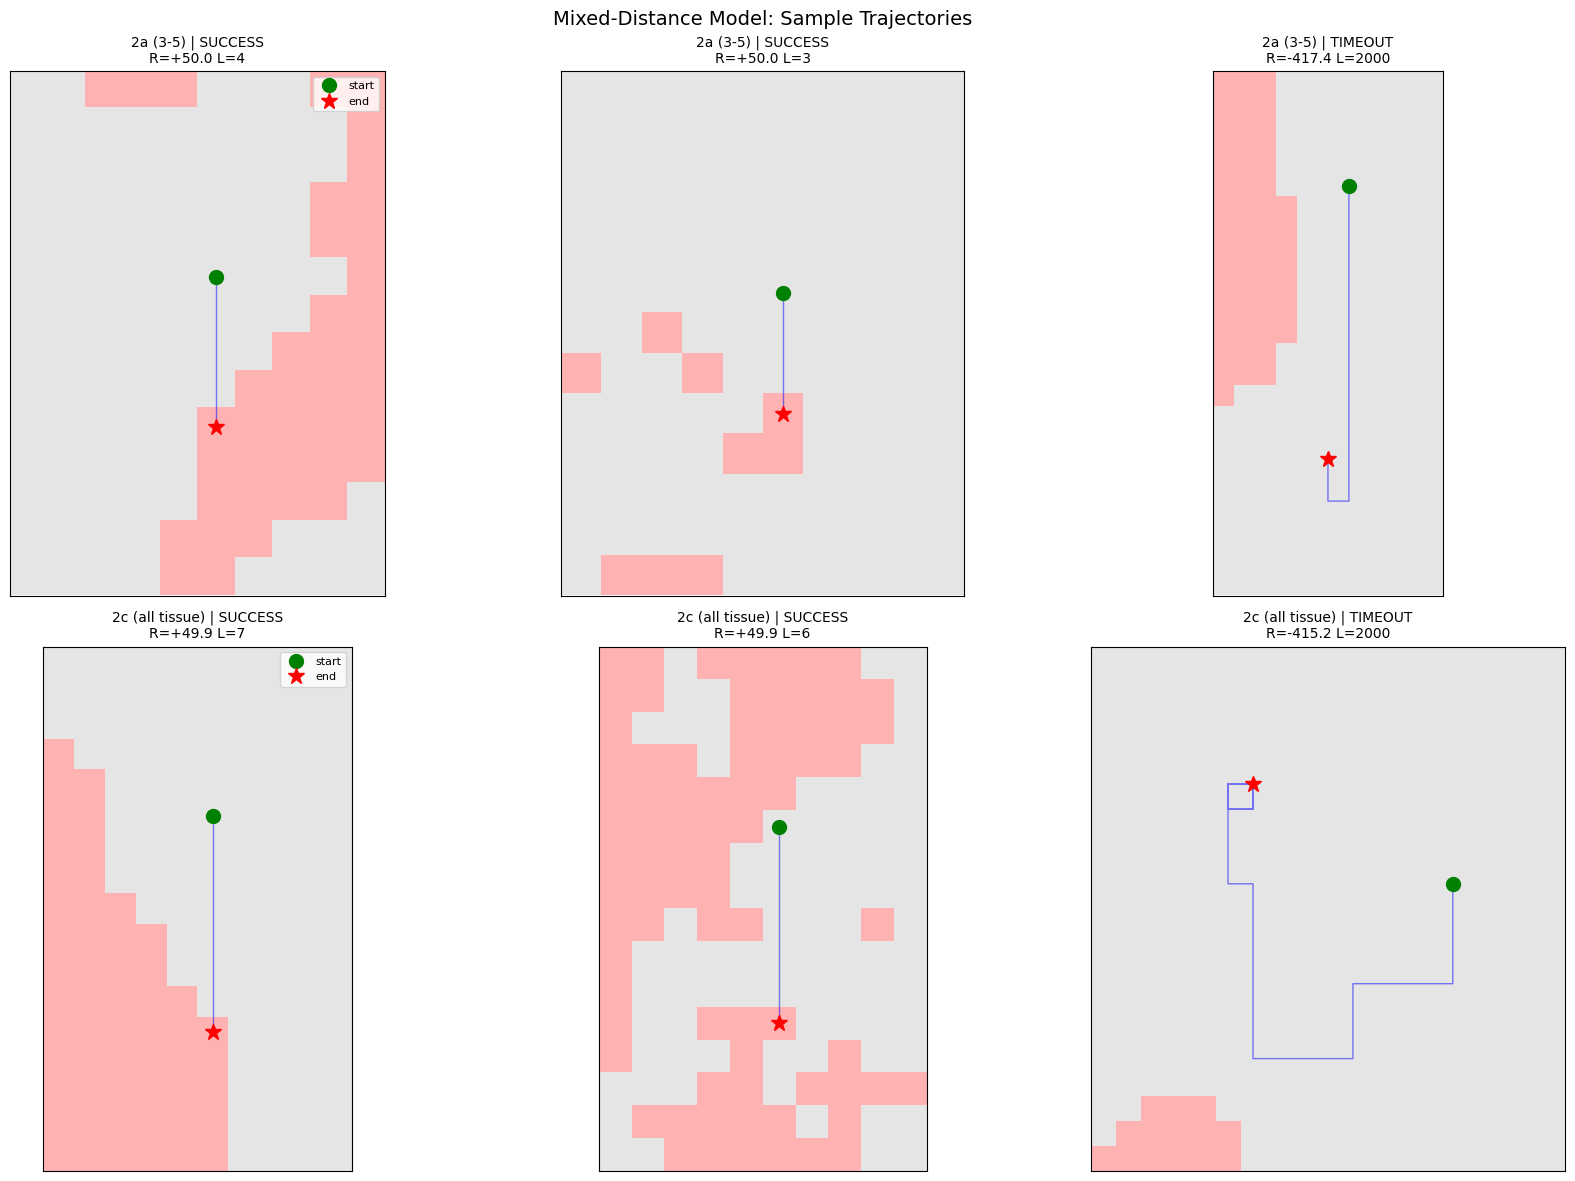

In [ ]:
# Trajectory visualization for mixed-distance model
n_show = 3
fig, axes = plt.subplots(2, n_show, figsize=(6 * n_show, 12))
fig.suptitle('Mixed-Distance Model: Sample Trajectories', fontsize=14)

unwrapped = env_v2.env if hasattr(env_v2, 'env') else env_v2

for row_i, (eval_name, mode, dr) in enumerate(
    [('2a (3-5)', 'distance_band', (3, 5)), ('2c (all tissue)', 'random_tissue', None)]
):
    res = eval_results_v2[eval_name]
    success_eps = [ep for ep in res if ep['success']]
    fail_eps = [ep for ep in res if not ep['success']]
    
    # show mix of success & fail
    show_eps = (success_eps[:min(2, len(success_eps))] + fail_eps[:min(1, len(fail_eps))])[:n_show]
    if len(show_eps) < n_show:
        show_eps += res[:n_show - len(show_eps)]

    for col_i, ep in enumerate(show_eps):
        ax = axes[row_i, col_i]
        traj = ep['trajectory']
        traj_r = [t[0] for t in traj]; traj_c = [t[1] for t in traj]

        r_min, r_max = min(traj_r) - 5, max(traj_r) + 5
        c_min, c_max = min(traj_c) - 5, max(traj_c) + 5
        r_min, c_min = max(0, r_min), max(0, c_min)
        r_max = min(unwrapped.n_rows, r_max)
        c_max = min(unwrapped.n_cols, c_max)

        local_tissue = unwrapped.tissue_grid[r_min:r_max, c_min:c_max]
        local_tumor = unwrapped.tumor_grid[r_min:r_max, c_min:c_max]

        canvas = np.ones((*local_tissue.shape, 3))
        canvas[local_tissue] = [0.9, 0.9, 0.9]
        canvas[local_tumor] = [1.0, 0.7, 0.7]

        ax.imshow(canvas, origin='upper')

        shifted_r = [r - r_min for r in traj_r]
        shifted_c = [c - c_min for c in traj_c]
        ax.plot(shifted_c, shifted_r, 'b-', alpha=0.5, lw=1)
        ax.plot(shifted_c[0], shifted_r[0], 'go', ms=10, label='start')
        ax.plot(shifted_c[-1], shifted_r[-1], 'r*', ms=12, label='end')

        status = "SUCCESS" if ep['success'] else "TIMEOUT"
        ax.set_title(f"{eval_name} | {status}\nR={ep['reward']:+.1f} L={ep['length']}", fontsize=10)
        if col_i == 0:
            ax.legend(fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

### 8.3 Analysis & Takeaways

| Model | 2a (3–5 steps) | 2b (10–20 steps) | 2c (all tissue) |
|-------|---------------|-----------------|----------------|
| Curriculum (sequential) | 32% | 8% | 2% |
| Mixed-distance | 48% | 20% | 6% |

**The agent never learned to navigate — it just learned to walk straight down.**

The trajectory plots make this obvious. Every successful episode is a nearly vertical line. When the tumor happens to be directly below the start, the agent "succeeds." When it isn't, the agent walks off the slide and times out. Both models do exactly the same thing.

**The success numbers are misleading.** The 48%/20%/6% figures from the mixed-distance model don't reflect any navigation skill — they reflect the geometric probability that the tumor lands directly below a random start. Farther starts naturally have a lower hit rate, which explains the drop.

**Both training strategies failed.** The sequential curriculum suffered catastrophic forgetting: later stages overwrote the policy from earlier ones. The mixed-distance approach avoided forgetting but still converged to the same degenerate strategy. The slightly higher numbers are noise, not improved navigation.

**The root cause is the observation space.** Tile embeddings encode visual appearance ("what does this patch look like?"), not spatial relationship ("which direction is the tumor?"). In CAMELYON16, normal tissue near and far from a tumor is nearly indistinguishable in feature space. There is no gradient pointing the agent toward the tumor, so it learns to ignore observations entirely and fix on a single direction.

This is not a hyperparameter problem. No amount of tuning or training time can fix a representation that fundamentally lacks the information needed to solve the task. The short-distance successes in stage 2a are just what you'd expect from a random walk in a small neighborhood — not evidence of actual navigation.

In [20]:
# Save models
model_v2.save(f"ppo_mixed_{RUN_TAG_V2}")
model.save(f"ppo_curriculum_{RUN_TAG}")
print(f"Saved: ppo_mixed_{RUN_TAG_V2}.zip")
print(f"Saved: ppo_curriculum_{RUN_TAG}.zip")

Saved: ppo_mixed_mixed_20260323_005812.zip
Saved: ppo_curriculum_curriculum_20260323_002817.zip


## 9. Why (6_1) Exists

Section 8.3 points to the core problem: the observation space lacks directional information, so the agent defaults to a fixed-direction strategy. But the experiments in this notebook have a few legitimate holes that leave room for doubt:

**The distance jumps were too coarse.** Stage 2a covers 3–5 steps and 2b jumps straight to 10–20. Someone could argue that the gap — skipping the 5–10 step range — made the transition too abrupt, not a fundamental limitation.

**Training might have been too short.** Total budget is under 1M steps (200K + 300K + 500K). Maybe the agent simply hadn't converged yet.

**Section 8's fix changed too many variables at once.** Switching from sequential to mixed-distance training also involved changing the network size (64→256), gamma, n_steps, and batch_size simultaneously. The 48% vs 32% improvement is uninterpretable — we can't tell which change caused it.

**(6_1)** runs a controlled experiment to close each of these gaps:
- Distance stages are 3–5 → 5–10 → 10–20 (smooth transitions, no big jumps)
- Each stage gets **1M steps** (3M total) — hard to argue underfitting at this scale
- Everything else (architecture, hyperparameters, reward design) stays identical to this notebook
- Added cross-stage forgetting checks and batch trajectory exports (30 PNGs per stage) for closer inspection

The results confirm the same pattern: even with finer-grained stages and ample training, each stage produces a different fixed-direction strategy (2a walks up, 2b walks left, 2c walks down). Cross-stage success rates land in the 35–58% range regardless of distance pool, with no meaningful improvement across runs.

This rules out training strategy as an explanation and pins the failure on the observation space itself.

> See `(6_1)Single_WSI_Curriculum1.ipynb`